In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [2]:
!pip install torch torchvision matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 223.3 kB/s eta 0:00:0000:0100:01
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-macosx_11_0_arm64.whl (63 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
You should consider upgrading via the '/Users/akhileshkumar/.pyenv/versions/3.10.5/bin/python3.10 -m pip install --upgrade pip' command.


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f'Train: {len(train_dataset)} | Test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:27<00:00, 366kB/s] 
100%|██████████| 28.9k/28.9k [00:01<00:00, 14.9kB/s]
100%|██████████| 1.65M/1.65M [00:09<00:00, 173kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.50MB/s]

Train: 60000 | Test: 10000


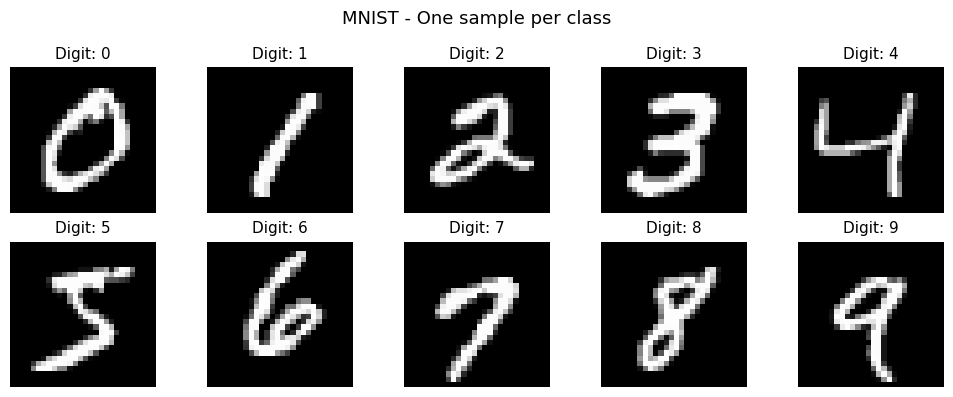

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

shown = {}
for img, lbl in train_dataset:
    if lbl not in shown:
        shown[lbl] = img
    if len(shown) == 10:
        break

for i in range(10):
    axes[i].imshow(shown[i].squeeze(), cmap='gray')
    axes[i].set_title(f'Digit: {i}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('MNIST - One sample per class', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
class MnistCNN(nn.Module):
    def __init__(self):
        super(MnistCNN, self).__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(2),                             

            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2)                           
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)          
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

model = MnistCNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

MnistCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 824,458


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10
train_losses, test_accs = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels.to(device)).sum().item()

    acc = 100. * correct / total
    test_accs.append(acc)
    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] Loss: {avg_loss:.4f} | Test Accuracy: {acc:.2f}%')

print('\nTraining complete!')

Epoch [ 1/10] Loss: 0.1891 | Test Accuracy: 98.49%
Epoch [ 2/10] Loss: 0.0630 | Test Accuracy: 98.83%
Epoch [ 3/10] Loss: 0.0454 | Test Accuracy: 99.11%
Epoch [ 4/10] Loss: 0.0385 | Test Accuracy: 99.15%
Epoch [ 5/10] Loss: 0.0289 | Test Accuracy: 99.22%
Epoch [ 6/10] Loss: 0.0269 | Test Accuracy: 99.32%
Epoch [ 7/10] Loss: 0.0225 | Test Accuracy: 99.16%
Epoch [ 8/10] Loss: 0.0202 | Test Accuracy: 99.30%
Epoch [ 9/10] Loss: 0.0162 | Test Accuracy: 99.22%
Epoch [10/10] Loss: 0.0159 | Test Accuracy: 99.32%

Training complete!


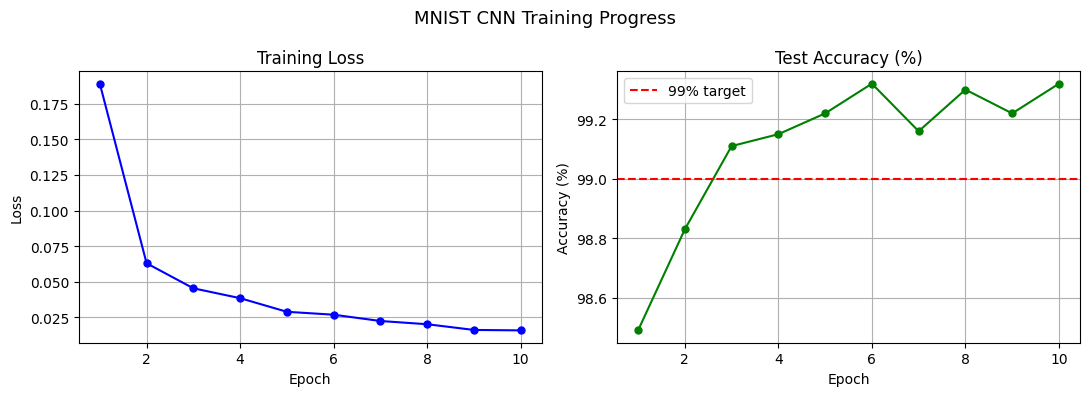

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, 'b-o', markersize=5)
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(epochs, test_accs, 'g-o', markersize=5)
ax2.set_title('Test Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.axhline(y=99, color='r', linestyle='--', label='99% target')
ax2.legend(); ax2.grid(True)

plt.suptitle('MNIST CNN Training Progress', fontsize=13)
plt.tight_layout()
plt.show()

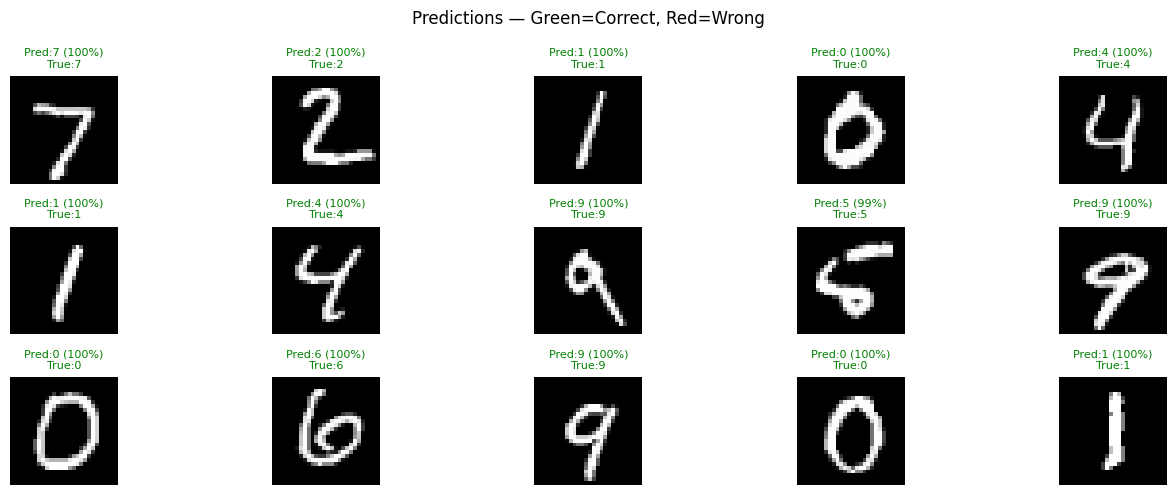

In [9]:
model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)
outputs = model(images.to(device))
_, predicted = outputs.max(1)

probs = torch.softmax(outputs, dim=1)
confidence, _ = probs.max(1)

plt.figure(figsize=(14, 5))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predicted[i].item() == labels[i].item() else 'red'
    plt.title(f'Pred:{predicted[i].item()} ({confidence[i].item():.0%})\nTrue:{labels[i].item()}',
              fontsize=8, color=color)
    plt.axis('off')

plt.suptitle('Predictions — Green=Correct, Red=Wrong', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 159.4 kB/s eta 0:00:00a 0:00:01
You should consider upgrading via the '/Users/akhileshkumar/.pyenv/versions/3.10.5/bin/python3.10 -m pip install --upgrade pip' command.


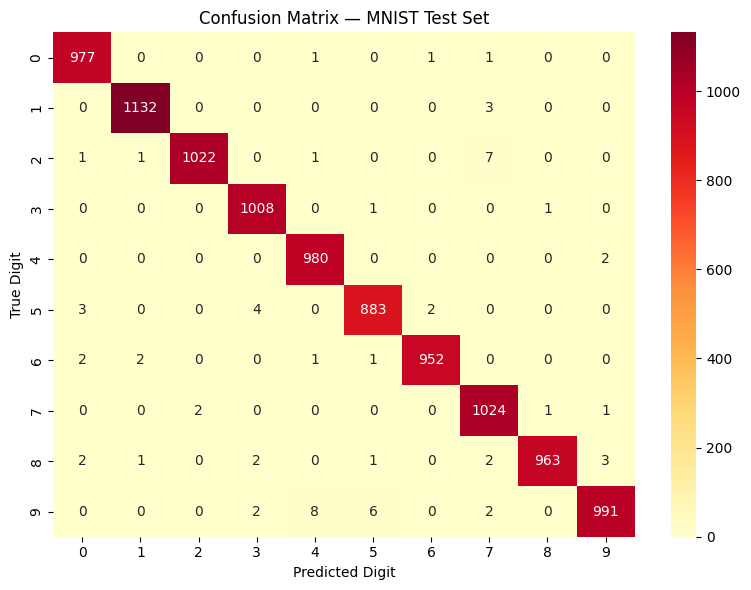

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Confusion Matrix — MNIST Test Set')
plt.xlabel('Predicted Digit'); plt.ylabel('True Digit')
plt.tight_layout()
plt.show()

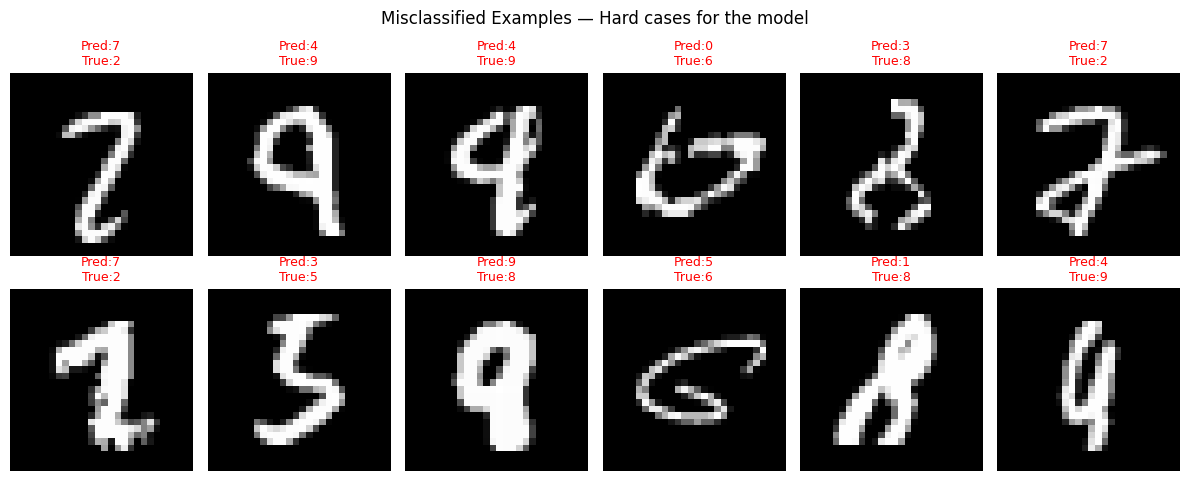

In [13]:
wrong_imgs, wrong_preds, wrong_true = [], [], []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = outputs.max(1)
        mask = preds.cpu() != labels
        wrong_imgs.extend(images[mask])
        wrong_preds.extend(preds.cpu()[mask].numpy())
        wrong_true.extend(labels[mask].numpy())
        if len(wrong_imgs) >= 12:
            break

plt.figure(figsize=(12, 5))
for i in range(min(12, len(wrong_imgs))):
    plt.subplot(2, 6, i+1)
    plt.imshow(wrong_imgs[i].squeeze(), cmap='gray')
    plt.title(f'Pred:{wrong_preds[i]}\nTrue:{wrong_true[i]}',
              fontsize=9, color='red')
    plt.axis('off')
plt.suptitle('Misclassified Examples — Hard cases for the model', fontsize=12)
plt.tight_layout()
plt.show()